In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

# --- 1. FETCH & CLEAN RAW DATA ---
print("Fetching Data...")
tickers = {
    'Nifty': '^NSEI',
    'USD_INR': 'INR=X',
    'Crude_Oil': 'CL=F',
    'Gold': 'GC=F',
    'US_10Y': '^TNX'
}

data = yf.download(list(tickers.values()), period='5y', interval='1d', progress=False)['Close']
data.columns = list(tickers.keys())
data.ffill(inplace=True)

# --- 2. UPGRADED FEATURE ENGINEERING (TIME-WINDOW OPTIMIZATION) ---
def engineer_optimized_features(df, column_name):
    """Generates pure Volatility and Multi-Timeframe Shock metrics"""

    # A. The Baseline Fear Gauge (Keep the 20-day volatility, it ranked highly!)
    daily_ret = df[column_name].pct_change()
    df[f'{column_name}_Vol_20d'] = daily_ret.rolling(window=20).std()

    # B. The Multi-Window Shock Race (5-day, 10-day, 20-day Z-Scores)
    # We add 1e-8 to the standard deviation to prevent "Division by Zero" errors on flat days
    windows = [5, 10, 20]
    for w in windows:
        rolling_mean = df[column_name].rolling(window=w).mean()
        rolling_std = df[column_name].rolling(window=w).std() + 1e-8
        df[f'{column_name}_ZScore_{w}d'] = (df[column_name] - rolling_mean) / rolling_std

    return df

# Apply the new logic
macro_variables = ['USD_INR', 'Crude_Oil', 'Gold', 'US_10Y']
for macro in macro_variables:
    data = engineer_optimized_features(data, macro)

# Drop the first 20 days where the moving averages were calculating
data.dropna(inplace=True)

# --- 3. DEFINING THE TARGET (Same as before) ---
lookahead = 5
data['Future_5d_Ret'] = data['Nifty'].pct_change(lookahead).shift(-lookahead)
data['Future_Absolute_Move'] = data['Future_5d_Ret'].abs()

# Top 25% Volatility Threshold
volatility_threshold = data['Future_Absolute_Move'].quantile(0.75)
data['Target_High_Vol'] = np.where(data['Future_Absolute_Move'] > volatility_threshold, 1, 0)
data.dropna(inplace=True)

# Define X and y (Notice we dropped the raw Momentum and 50d columns entirely!)
X = data.drop(['Nifty', 'Future_5d_Ret', 'Future_Absolute_Move', 'Target_High_Vol'], axis=1)
y = data['Target_High_Vol']

print(f"\nOptimization Complete! Total columns: {len(X.columns)}")

Fetching Data...


/tmp/ipykernel_6374/1964272888.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(list(tickers.values()), period='5y', interval='1d', progress=False)['Close']



Optimization Complete! Total columns: 20


In [4]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np

print("\nInitializing the Version 3.0 Sniper Engine...")

# --- 1. PRUNE THE DEAD WEIGHT ---
# We are keeping ONLY the top 11 features from your exact chart
# We violently delete the 5-day and most 10-day noise.
keepers = [
    'US_10Y', 'US_10Y_Vol_20d', 'Crude_Oil_ZScore_20d',
    'US_10Y_ZScore_20d', 'Gold', 'Gold_Vol_20d',
    'Gold_ZScore_20d', 'USD_INR', 'USD_INR_Vol_20d',
    'Crude_Oil_Vol_20d', 'USD_INR_ZScore_10d'
]

# Redefine X to ONLY include the elite keepers
X_pruned = X[keepers]

# --- 2. WALK-FORWARD ENGINE ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    scale_pos_weight=3,
    random_state=42,
    eval_metric='logloss'
)

fold_accuracies = []
fold_precisions = []
fold_recalls = []

print("\n--- Out-of-Sample Performance by Fold ---")
fold = 1

for train_index, test_index in tscv.split(X_pruned):
    X_train, X_test = X_pruned.iloc[train_index], X_pruned.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    xgb_model.fit(X_train, y_train)

    # --- 3. THE SNIPER THRESHOLD ---
    # Extract the raw mathematical probability (0.0 to 1.0)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

    # Force the model to be 70% confident to trigger a trade (instead of 51%)
    custom_threshold = 0.70
    y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

    # Evaluate using the custom, highly-conservative predictions
    acc = accuracy_score(y_test, y_pred_custom)
    prec = precision_score(y_test, y_pred_custom, zero_division=0)
    rec = recall_score(y_test, y_pred_custom, zero_division=0)

    fold_accuracies.append(acc)
    fold_precisions.append(prec)
    fold_recalls.append(rec)

    print(f"Fold {fold} | Accuracy: {acc:.2%} | Precision: {prec:.2%} | Recall: {rec:.2%}")
    fold += 1

print("\n" + "="*40)
print(f"Final Average Accuracy:  {np.mean(fold_accuracies):.2%}")
print(f"Final Average Precision: {np.mean(fold_precisions):.2%}")
print(f"Final Average Recall:    {np.mean(fold_recalls):.2%}")
print("="*40)


Initializing the Version 3.0 Sniper Engine...

--- Out-of-Sample Performance by Fold ---
Fold 1 | Accuracy: 60.09% | Precision: 100.00% | Recall: 1.16%
Fold 2 | Accuracy: 67.14% | Precision: 35.00% | Recall: 10.94%
Fold 3 | Accuracy: 77.46% | Precision: 10.53% | Recall: 6.06%
Fold 4 | Accuracy: 77.00% | Precision: 0.00% | Recall: 0.00%
Fold 5 | Accuracy: 78.40% | Precision: 50.00% | Recall: 2.17%

Final Average Accuracy:  72.02%
Final Average Precision: 39.11%
Final Average Recall:    4.07%


Retraining on full dataset to extract global alpha...


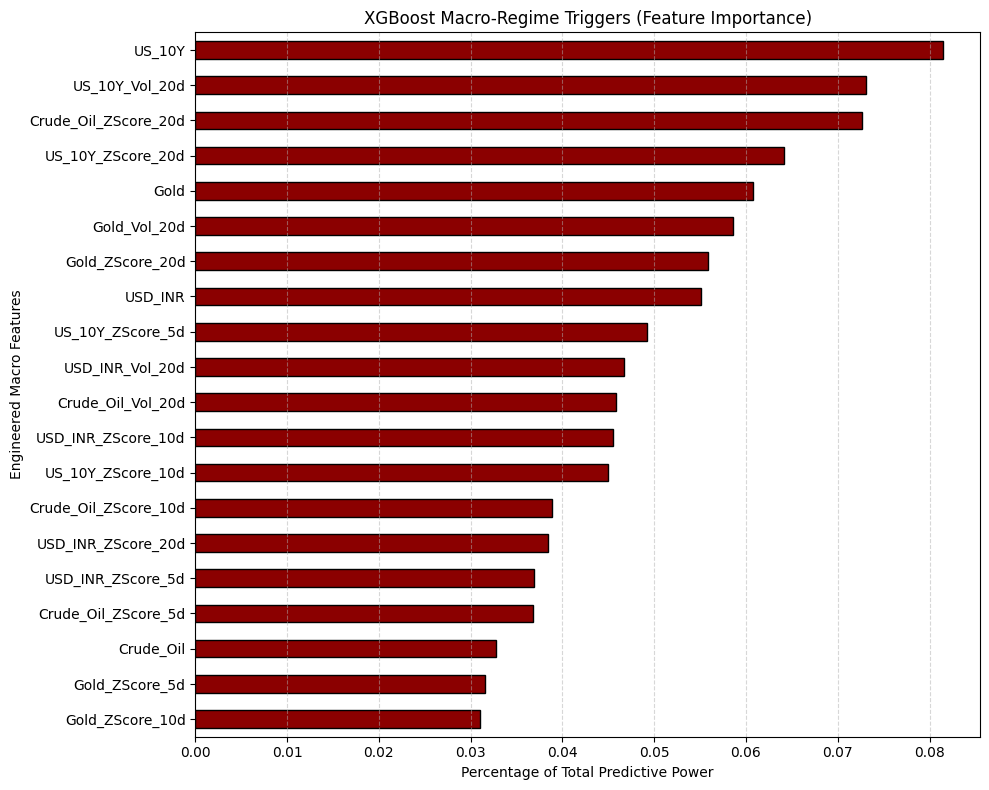

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

print("Retraining on full dataset to extract global alpha...")

# 1. Retrain the model on the full X and y
xgb_model.fit(X, y)

# 2. Extract the mathematically calculated Feature Importances (Gain)
importances = xgb_model.feature_importances_

# 3. Bind the scores to the column names and sort them
feature_names = X.columns
importance_series = pd.Series(importances, index=feature_names)
importance_series = importance_series.sort_values(ascending=True)

# 4. Visualize the Brain of the Model
plt.figure(figsize=(10, 8))
importance_series.plot(kind='barh', color='darkred', edgecolor='black')

plt.title("XGBoost Macro-Regime Triggers (Feature Importance)")
plt.xlabel("Percentage of Total Predictive Power")
plt.ylabel("Engineered Macro Features")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()